# 06 — Exploratory Data Analysis

## Leadership and Management Book Recommendation System

### Objective

This notebook explores the final integrated leadership and management book dataset to identify:

- dataset structure and metadata coverage
- source composition
- publication patterns
- authorship patterns
- category and subject patterns
- rating and reader-engagement distributions
- edition characteristics
- missing-data patterns
- potential outliers and skewness
- variables suitable for later NLP, feature engineering, clustering, and recommendation modelling

The analysis is descriptive and exploratory. Source-derived categories, ratings, and engagement measures are treated as observed metadata and are not interpreted as objective measures of book quality.

### Final Integrated Dataset

The relational database contains:

- **2,067 canonical books**
- **2,281 authors**
- **2,187 categories**
- **2,566 book-author relationships**
- **5,926 book-category relationships**
- **1,120 LeadershipNow edition records**
- **950 Open Library metric records**
- **2,070 source records**
- **3 confirmed cross-source book matches**

Missing metadata will remain missing unless a defensible external enrichment source is introduced later.

In [2]:
# ============================================================
# 06 - EXPLORATORY DATA ANALYSIS
# Leadership & Management Book Recommendation System
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/Users/jannoelvero/Documents/Ironhack/Week_11/"
    "Leadership_Management_Book_Recommendation_System"
)

DATA_FINAL = PROJECT_ROOT / "data" / "final"

books_path = DATA_FINAL / "books_master.csv"
editions_path = DATA_FINAL / "leadershipnow_editions.csv"
openlibrary_path = DATA_FINAL / "openlibrary_integrated.csv"

# ------------------------------------------------------------
# Confirm files
# ------------------------------------------------------------

print("Project root:")
print(PROJECT_ROOT)

print("\nFiles:")
print(f"Books master:       {books_path.exists()} | {books_path}")
print(f"Edition data:       {editions_path.exists()} | {editions_path}")
print(f"Open Library data:  {openlibrary_path.exists()} | {openlibrary_path}")

Project root:
/Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System

Files:
Books master:       True | /Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/data/final/books_master.csv
Edition data:       True | /Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/data/final/leadershipnow_editions.csv
Open Library data:  True | /Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/data/final/openlibrary_integrated.csv


In [3]:
# ============================================================
# LOAD FINAL DATASETS
# ============================================================

books = pd.read_csv(books_path)
editions = pd.read_csv(editions_path)
openlibrary = pd.read_csv(openlibrary_path)

print("DATASETS LOADED")
print("=" * 60)

print(f"Books master:       {books.shape[0]:,} rows × {books.shape[1]} columns")
print(f"LeadershipNow:      {editions.shape[0]:,} rows × {editions.shape[1]} columns")
print(f"Open Library:       {openlibrary.shape[0]:,} rows × {openlibrary.shape[1]} columns")

print("\nBOOKS MASTER COLUMNS")
print("=" * 60)

for i, col in enumerate(books.columns, start=1):
    print(f"{i:>2}. {col}")

print("\nBASELINE IDENTIFIER CHECK")
print("=" * 60)

print(f"Total books:              {len(books):,}")
print(f"Unique book IDs:          {books['book_id'].nunique():,}")
print(f"Missing book IDs:         {books['book_id'].isna().sum():,}")
print(f"Duplicate book IDs:       {books['book_id'].duplicated().sum():,}")

# Source flags
ol_flag = books["source_openlibrary"].fillna(False).astype(bool)
ln_flag = books["source_leadershipnow"].fillna(False).astype(bool)

ol_only = (ol_flag & ~ln_flag).sum()
ln_only = (~ol_flag & ln_flag).sum()
both = (ol_flag & ln_flag).sum()
neither = (~ol_flag & ~ln_flag).sum()

print("\nSOURCE COMPOSITION")
print("=" * 60)

print(f"Open Library only:        {ol_only:,}")
print(f"LeadershipNow only:       {ln_only:,}")
print(f"Both sources:             {both:,}")
print(f"Neither source:           {neither:,}")

# Validation
assert len(books) == 2067
assert books["book_id"].nunique() == 2067
assert books["book_id"].isna().sum() == 0
assert books["book_id"].duplicated().sum() == 0

assert ol_only == 947
assert ln_only == 1117
assert both == 3
assert neither == 0

print("\n✓ BASELINE EDA VALIDATION PASSED")

DATASETS LOADED
Books master:       2,067 rows × 18 columns
LeadershipNow:      1,120 rows × 23 columns
Open Library:       950 rows × 50 columns

BOOKS MASTER COLUMNS
 1. book_id
 2. canonical_title
 3. authors
 4. description
 5. subjects
 6. first_publish_year
 7. average_rating
 8. ratings_count
 9. edition_count
10. want_to_read_count
11. currently_reading_count
12. already_read_count
13. cover_url
14. openlibrary_key
15. source_openlibrary
16. source_leadershipnow
17. publication_year_observed
18. title_normalized

BASELINE IDENTIFIER CHECK
Total books:              2,067
Unique book IDs:          2,067
Missing book IDs:         0
Duplicate book IDs:       0

SOURCE COMPOSITION
Open Library only:        947
LeadershipNow only:       1,117
Both sources:             3
Neither source:           0

✓ BASELINE EDA VALIDATION PASSED


In [5]:
# ============================================================
# LOAD FINAL DATASETS
# ============================================================

books = pd.read_csv(books_path)
editions = pd.read_csv(editions_path)
openlibrary = pd.read_csv(openlibrary_path)

print("DATASETS LOADED")
print("=" * 60)

print(f"Books master:       {books.shape[0]:,} rows × {books.shape[1]} columns")
print(f"LeadershipNow:      {editions.shape[0]:,} rows × {editions.shape[1]} columns")
print(f"Open Library:       {openlibrary.shape[0]:,} rows × {openlibrary.shape[1]} columns")

print("\nBOOKS MASTER COLUMNS")
print("=" * 60)

for i, col in enumerate(books.columns, start=1):
    print(f"{i:>2}. {col}")

print("\nBASELINE IDENTIFIER CHECK")
print("=" * 60)

print(f"Total books:              {len(books):,}")
print(f"Unique book IDs:          {books['book_id'].nunique():,}")
print(f"Missing book IDs:         {books['book_id'].isna().sum():,}")
print(f"Duplicate book IDs:       {books['book_id'].duplicated().sum():,}")

# Source flags
ol_flag = books["source_openlibrary"].fillna(False).astype(bool)
ln_flag = books["source_leadershipnow"].fillna(False).astype(bool)

ol_only = (ol_flag & ~ln_flag).sum()
ln_only = (~ol_flag & ln_flag).sum()
both = (ol_flag & ln_flag).sum()
neither = (~ol_flag & ~ln_flag).sum()

print("\nSOURCE COMPOSITION")
print("=" * 60)

print(f"Open Library only:        {ol_only:,}")
print(f"LeadershipNow only:       {ln_only:,}")
print(f"Both sources:             {both:,}")
print(f"Neither source:           {neither:,}")

# Validation
assert len(books) == 2067
assert books["book_id"].nunique() == 2067
assert books["book_id"].isna().sum() == 0
assert books["book_id"].duplicated().sum() == 0

assert ol_only == 947
assert ln_only == 1117
assert both == 3
assert neither == 0

print("\n✓ BASELINE EDA VALIDATION PASSED")

DATASETS LOADED
Books master:       2,067 rows × 18 columns
LeadershipNow:      1,120 rows × 23 columns
Open Library:       950 rows × 50 columns

BOOKS MASTER COLUMNS
 1. book_id
 2. canonical_title
 3. authors
 4. description
 5. subjects
 6. first_publish_year
 7. average_rating
 8. ratings_count
 9. edition_count
10. want_to_read_count
11. currently_reading_count
12. already_read_count
13. cover_url
14. openlibrary_key
15. source_openlibrary
16. source_leadershipnow
17. publication_year_observed
18. title_normalized

BASELINE IDENTIFIER CHECK
Total books:              2,067
Unique book IDs:          2,067
Missing book IDs:         0
Duplicate book IDs:       0

SOURCE COMPOSITION
Open Library only:        947
LeadershipNow only:       1,117
Both sources:             3
Neither source:           0

✓ BASELINE EDA VALIDATION PASSED


## 2. Data Quality and Metadata Coverage

Metadata completeness is assessed before exploratory modelling.

Because the dataset integrates two sources with different data structures, missing values are expected and should not automatically be interpreted as data-quality errors. In particular, ratings and reader-engagement metrics originate primarily from Open Library, while LeadershipNow contributes edition-level bibliographic information.

The objective of this section is to identify which variables have sufficient coverage for descriptive analysis and later recommendation-system features.

In [6]:
# ============================================================
# METADATA COVERAGE ANALYSIS
# ============================================================

coverage_columns = [
    "canonical_title",
    "authors",
    "description",
    "subjects",
    "first_publish_year",
    "publication_year_observed",
    "average_rating",
    "ratings_count",
    "edition_count",
    "want_to_read_count",
    "currently_reading_count",
    "already_read_count",
    "cover_url",
    "openlibrary_key",
]

coverage_results = []

for col in coverage_columns:
    
    # Count non-null values
    available = books[col].notna().sum()
    missing = books[col].isna().sum()
    
    coverage_pct = (available / len(books)) * 100
    missing_pct = (missing / len(books)) * 100
    
    coverage_results.append({
        "variable": col,
        "available": available,
        "missing": missing,
        "coverage_pct": coverage_pct,
        "missing_pct": missing_pct
    })

coverage_df = pd.DataFrame(coverage_results)

coverage_df = coverage_df.sort_values(
    "coverage_pct",
    ascending=False
).reset_index(drop=True)

print("METADATA COVERAGE")
print("=" * 80)

display(
    coverage_df.style.format({
        "coverage_pct": "{:.2f}%",
        "missing_pct": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# Core text-feature availability
# ------------------------------------------------------------

has_title = books["canonical_title"].notna()
has_author = books["authors"].notna()
has_description = books["description"].notna()
has_subjects = books["subjects"].notna()

print("\nCORE TEXT FEATURE AVAILABILITY")
print("=" * 80)

print(
    f"Title available:             "
    f"{has_title.sum():,} / {len(books):,} "
    f"({has_title.mean() * 100:.2f}%)"
)

print(
    f"Author available:            "
    f"{has_author.sum():,} / {len(books):,} "
    f"({has_author.mean() * 100:.2f}%)"
)

print(
    f"Description available:       "
    f"{has_description.sum():,} / {len(books):,} "
    f"({has_description.mean() * 100:.2f}%)"
)

print(
    f"Subjects available:          "
    f"{has_subjects.sum():,} / {len(books):,} "
    f"({has_subjects.mean() * 100:.2f}%)"
)

print(
    f"Description OR subjects:     "
    f"{(has_description | has_subjects).sum():,} / {len(books):,} "
    f"({(has_description | has_subjects).mean() * 100:.2f}%)"
)

print(
    f"Title + description/subjects:"
    f" {(has_title & (has_description | has_subjects)).sum():,} / "
    f"{len(books):,} "
    f"({(has_title & (has_description | has_subjects)).mean() * 100:.2f}%)"
)

METADATA COVERAGE


,variable,available,missing,coverage_pct,missing_pct
0,canonical_title,2067,0,100.00%,0.00%
1,authors,2067,0,100.00%,0.00%
2,subjects,2067,0,100.00%,0.00%
3,cover_url,1888,179,91.34%,8.66%
4,publication_year_observed,1117,950,54.04%,45.96%
5,edition_count,950,1117,45.96%,54.04%
6,openlibrary_key,950,1117,45.96%,54.04%
7,first_publish_year,947,1120,45.82%,54.18%
8,want_to_read_count,807,1260,39.04%,60.96%
9,currently_reading_count,807,1260,39.04%,60.96%



CORE TEXT FEATURE AVAILABILITY
Title available:             2,067 / 2,067 (100.00%)
Author available:            2,067 / 2,067 (100.00%)
Description available:       192 / 2,067 (9.29%)
Subjects available:          2,067 / 2,067 (100.00%)
Description OR subjects:     2,067 / 2,067 (100.00%)
Title + description/subjects: 2,067 / 2,067 (100.00%)


In [7]:
# ============================================================
# SEMANTIC MISSINGNESS CHECK FOR TEXT / LIST-LIKE FIELDS
# ============================================================

def inspect_text_values(series, n=15):
    """
    Show the most frequent string representations,
    including placeholders such as [], nan, None, etc.
    """
    cleaned = series.astype(str).str.strip()

    return (
        cleaned
        .value_counts(dropna=False)
        .head(n)
    )


print("AUTHORS — MOST COMMON RAW REPRESENTATIONS")
print("=" * 70)
display(inspect_text_values(books["authors"]))


print("\nSUBJECTS — MOST COMMON RAW REPRESENTATIONS")
print("=" * 70)
display(inspect_text_values(books["subjects"]))


print("\nDESCRIPTION — MOST COMMON RAW REPRESENTATIONS")
print("=" * 70)
display(inspect_text_values(books["description"]))


# ------------------------------------------------------------
# Explicit placeholder counts
# ------------------------------------------------------------

placeholder_values = {
    "",
    "[]",
    "{}",
    "nan",
    "none",
    "null",
    "na",
    "n/a"
}


def count_semantically_missing(series):
    normalized = (
        series
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    return normalized.isin(placeholder_values).sum()


print("\nSEMANTICALLY MISSING VALUES")
print("=" * 70)

for col in ["authors", "subjects", "description"]:
    missing_count = count_semantically_missing(books[col])
    available_count = len(books) - missing_count

    print(
        f"{col:<15}"
        f" available = {available_count:>5,}"
        f" | missing = {missing_count:>5,}"
        f" | coverage = {available_count / len(books) * 100:>6.2f}%"
    )

AUTHORS — MOST COMMON RAW REPRESENTATIONS


authors
['Michael Armstrong']               9
[]                                  8
['Gary Dessler']                    8
['John C. Maxwell']                 6
['Fred R. David']                   5
['Project Management Institute']    5
['William J. Stevenson']            5
['BPP Learning Media']              5
['Bruce J. Avolio']                 4
['Jay Heizer']                      4
['Daniel Goleman']                  4
['Donald Miller']                   4
['Bernard M. Bass']                 3
['Patrick Lencioni']                3
['Marvin Bower']                    3
Name: count, dtype: int64


SUBJECTS — MOST COMMON RAW REPRESENTATIONS


subjects
[]                                                1241
['Personnel management']                            20
['Leadership']                                      17
['Project management']                              12
['Business']                                         6
['Production management']                            6
['Management']                                       5
['Economics']                                        5
['Emotional intelligence']                           5
['Executive ability', 'Leadership']                  4
['Organizational behavior']                          4
['Leadership', 'Organizational effectiveness']       3
['Commerce']                                         3
['Case studies', 'Strategic planning']               3
['Strategic planning', 'Management']                 3
Name: count, dtype: int64


DESCRIPTION — MOST COMMON RAW REPRESENTATIONS


description
NaN                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         


SEMANTICALLY MISSING VALUES
authors         available = 2,059 | missing =     8 | coverage =  99.61%
subjects        available =   826 | missing = 1,241 | coverage =  39.96%
description     available =   192 | missing = 1,875 | coverage =   9.29%


## 3. Metadata Coverage Analysis

Metadata availability varies substantially across the integrated dataset because Open Library and LeadershipNow contribute different types of information.

For list-like text fields such as authors and subjects, serialized empty lists (`[]`) are treated as semantically missing rather than available metadata.

Understanding this coverage is important for determining which variables can be used reliably in later descriptive analysis, NLP, clustering, and recommendation modelling.

,variable,available,missing,coverage_pct
12,canonical_title,2067,0,100.00%
11,authors,2059,8,99.61%
10,cover_url,1888,179,91.34%
9,publication_year_observed,1117,950,54.04%
8,edition_count,950,1117,45.96%
7,first_publish_year,947,1120,45.82%
6,subjects,826,1241,39.96%
3,want_to_read_count,807,1260,39.04%
4,currently_reading_count,807,1260,39.04%
5,already_read_count,807,1260,39.04%


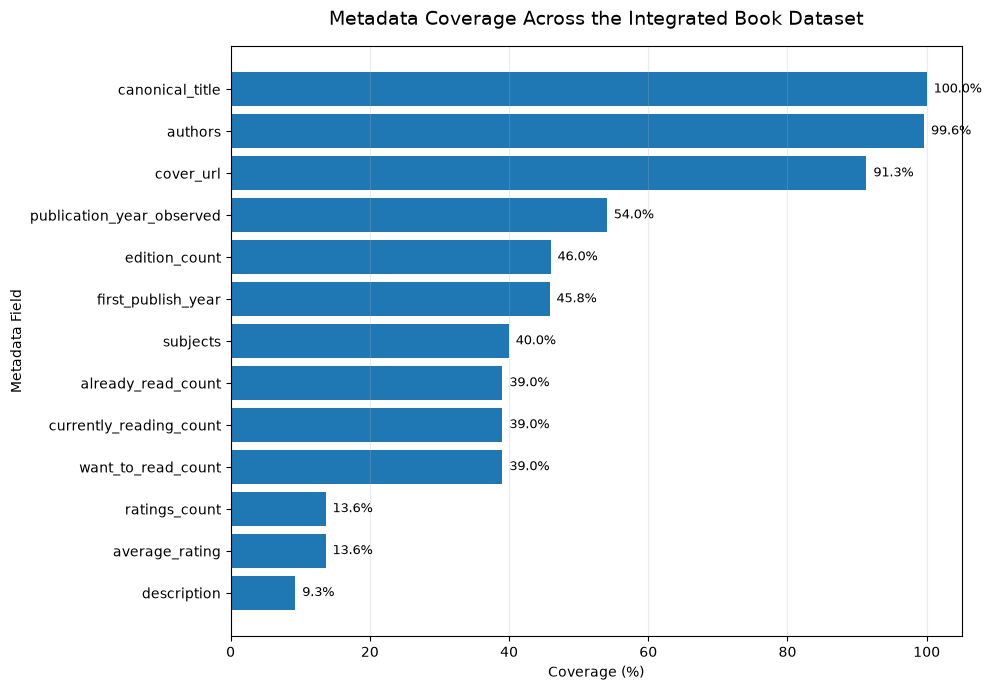

In [8]:
# ============================================================
# CORRECTED SEMANTIC METADATA COVERAGE
# ============================================================

def semantic_available(series):
    """
    Returns True when a value contains meaningful metadata.
    Handles NaN and serialized empty-list placeholders.
    """
    normalized = (
        series
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    placeholders = {
        "",
        "[]",
        "{}",
        "nan",
        "none",
        "null",
        "na",
        "n/a"
    }

    return ~normalized.isin(placeholders)


metadata_fields = [
    "canonical_title",
    "authors",
    "subjects",
    "description",
    "first_publish_year",
    "publication_year_observed",
    "average_rating",
    "ratings_count",
    "edition_count",
    "want_to_read_count",
    "currently_reading_count",
    "already_read_count",
    "cover_url"
]


coverage_records = []

for col in metadata_fields:

    available_mask = semantic_available(books[col])

    available = available_mask.sum()
    missing = len(books) - available
    coverage_pct = available / len(books) * 100

    coverage_records.append({
        "variable": col,
        "available": available,
        "missing": missing,
        "coverage_pct": coverage_pct
    })


semantic_coverage = (
    pd.DataFrame(coverage_records)
    .sort_values("coverage_pct", ascending=True)
    .reset_index(drop=True)
)


display(
    semantic_coverage.sort_values(
        "coverage_pct",
        ascending=False
    ).style.format({
        "coverage_pct": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    semantic_coverage["variable"],
    semantic_coverage["coverage_pct"]
)

ax.set_title(
    "Metadata Coverage Across the Integrated Book Dataset",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Coverage (%)")
ax.set_ylabel("Metadata Field")

ax.set_xlim(0, 105)

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, value in zip(
    bars,
    semantic_coverage["coverage_pct"]
):
    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Interpretation

Metadata coverage varies substantially across the 2,067-book integrated dataset.

- **Book titles have complete coverage (100%)**, making title information the most reliable universal feature.
- **Author information is nearly complete (99.61%)**, with only 8 books lacking usable author metadata.
- **Cover images are available for 91.34%** of books, providing strong coverage for the eventual recommendation-system interface.
- Publication-year information has moderate coverage. Observed publication year is available for **54.04%**, while first publication year is available for **45.82%**.
- **Subjects are available for 39.96%** of books. Although incomplete, they provide useful semantic information for content-based recommendation and NLP.
- Reader-engagement variables (`want_to_read`, `currently_reading`, and `already_read`) are available for **39.04%** of books.
- Ratings are substantially more sparse: only **13.64%** of books have an observed average rating and rating count.
- **Descriptions have the lowest coverage at 9.29%**, indicating that description-only NLP would exclude most of the catalogue.

These results support a **multi-feature content representation** rather than relying on a single metadata field. Later NLP and recommendation modelling should combine available information such as title, authors, subjects, and descriptions while preserving missing metadata rather than fabricating values.

Ratings and engagement variables should be treated as supplementary popularity signals rather than universal recommendation features because they are unavailable for most books.

## 4. Source Composition

The integrated catalogue combines records from Open Library and LeadershipNow.

Source composition is examined to understand how much each source contributes to the final catalogue and to confirm that cross-source entity resolution did not artificially inflate the number of books.

,source,book_count,percentage
0,LeadershipNow Only,1117,54.04%
1,Open Library Only,947,45.82%
2,Both Sources,3,0.15%


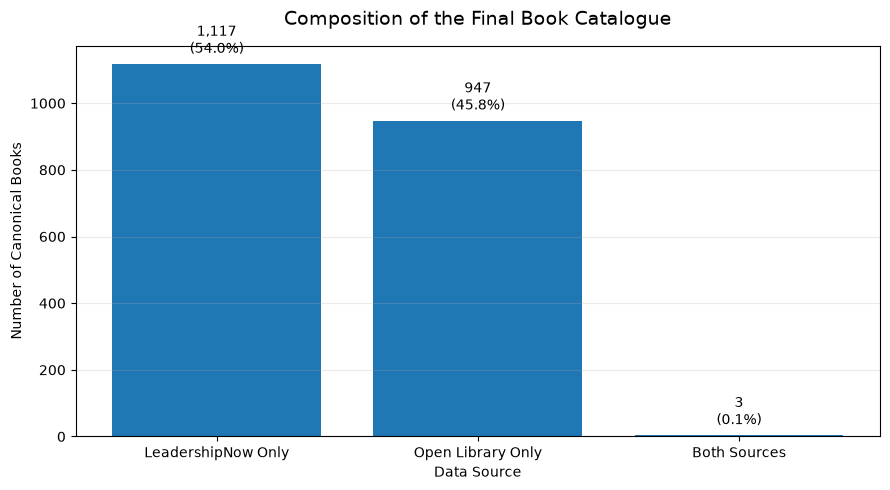

In [9]:
# ============================================================
# SOURCE COMPOSITION
# ============================================================

ol_flag = books["source_openlibrary"].astype(bool)
ln_flag = books["source_leadershipnow"].astype(bool)

source_group = np.select(
    [
        ol_flag & ~ln_flag,
        ~ol_flag & ln_flag,
        ol_flag & ln_flag
    ],
    [
        "Open Library Only",
        "LeadershipNow Only",
        "Both Sources"
    ],
    default="Unknown"
)

source_counts = (
    pd.Series(source_group, name="source")
    .value_counts()
    .rename_axis("source")
    .reset_index(name="book_count")
)

source_counts["percentage"] = (
    source_counts["book_count"] /
    len(books) * 100
)

display(
    source_counts.style.format({
        "percentage": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    source_counts["source"],
    source_counts["book_count"]
)

ax.set_title(
    "Composition of the Final Book Catalogue",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Data Source")
ax.set_ylabel("Number of Canonical Books")

ax.grid(
    axis="y",
    alpha=0.25
)

for bar, count, pct in zip(
    bars,
    source_counts["book_count"],
    source_counts["percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Interpretation

The final catalogue contains 2,067 unique canonical books drawn from two largely complementary data sources.

LeadershipNow contributes the largest share, with **1,117 source-exclusive books (54.04%)**, while Open Library contributes **947 source-exclusive books (45.82%)**. Only **3 books (0.15%)** were confirmed as representing the same canonical works across both sources.

The limited cross-source overlap indicates that combining the two sources substantially expanded catalogue coverage rather than merely duplicating records.

The sources also contribute different types of metadata. Open Library provides ratings, reader-engagement indicators, subjects, descriptions, and bibliographic information where available, while LeadershipNow contributes a substantial collection of recent leadership and management titles and edition-level metadata.

This source heterogeneity explains several of the missing-data patterns observed earlier. Therefore, missingness should be interpreted partly as a consequence of source-specific metadata availability rather than automatically as a data-quality failure.

## 5. Publication-Year Analysis

Two publication-year variables are retained because they represent different bibliographic concepts:

- `first_publish_year` represents the earliest available publication year for a canonical work.
- `publication_year_observed` represents the publication year observed in the LeadershipNow source.

These variables are analysed separately to avoid treating first publication and observed edition publication as equivalent events.

In [10]:
# ============================================================
# PUBLICATION YEAR BASELINE
# ============================================================

year_summary = pd.DataFrame({
    "metric": [
        "Available records",
        "Missing records",
        "Minimum year",
        "25th percentile",
        "Median year",
        "Mean year",
        "75th percentile",
        "Maximum year"
    ],

    "first_publish_year": [
        books["first_publish_year"].notna().sum(),
        books["first_publish_year"].isna().sum(),
        books["first_publish_year"].min(),
        books["first_publish_year"].quantile(0.25),
        books["first_publish_year"].median(),
        books["first_publish_year"].mean(),
        books["first_publish_year"].quantile(0.75),
        books["first_publish_year"].max()
    ],

    "publication_year_observed": [
        books["publication_year_observed"].notna().sum(),
        books["publication_year_observed"].isna().sum(),
        books["publication_year_observed"].min(),
        books["publication_year_observed"].quantile(0.25),
        books["publication_year_observed"].median(),
        books["publication_year_observed"].mean(),
        books["publication_year_observed"].quantile(0.75),
        books["publication_year_observed"].max()
    ]
})

display(
    year_summary.style.format({
        "first_publish_year": "{:,.2f}",
        "publication_year_observed": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# Check potentially implausible years
# ------------------------------------------------------------

current_year = 2026

print("PUBLICATION YEAR RANGE CHECK")
print("=" * 70)

print(
    "First publication before 1800:",
    (books["first_publish_year"] < 1800).sum()
)

print(
    "First publication after 2026:",
    (books["first_publish_year"] > current_year).sum()
)

print(
    "Observed publication before 1800:",
    (books["publication_year_observed"] < 1800).sum()
)

print(
    "Observed publication after 2026:",
    (books["publication_year_observed"] > current_year).sum()
)

,metric,first_publish_year,publication_year_observed
0,Available records,947.00,"1,117.00"
1,Missing records,"1,120.00",950.00
2,Minimum year,"1,900.00","2,022.00"
3,25th percentile,"1,993.50","2,022.00"
4,Median year,"2,004.00","2,023.00"
5,Mean year,"2,000.98","2,023.44"
6,75th percentile,"2,012.00","2,024.00"
7,Maximum year,"2,025.00","2,025.00"


PUBLICATION YEAR RANGE CHECK
First publication before 1800: 0
First publication after 2026: 0
Observed publication before 1800: 0
Observed publication after 2026: 0


### Publication-Year Baseline Interpretation

The two publication-year variables represent different temporal perspectives.

`first_publish_year` is available for 947 books and ranges from **1900 to 2025**, with a median of **2004** and a mean of approximately **2001**. This variable therefore captures a broad historical range of leadership and management literature.

`publication_year_observed` is available for 1,117 books and ranges only from **2022 to 2025**, with a median of **2023**. This reflects the recent-release orientation of the LeadershipNow collection rather than the historical age of the underlying works.

No publication years fall outside the expected range, so no temporal outliers require removal at this stage.

Because the two variables represent different bibliographic concepts and largely originate from different sources, they should remain separate rather than being combined into a single publication-year variable.

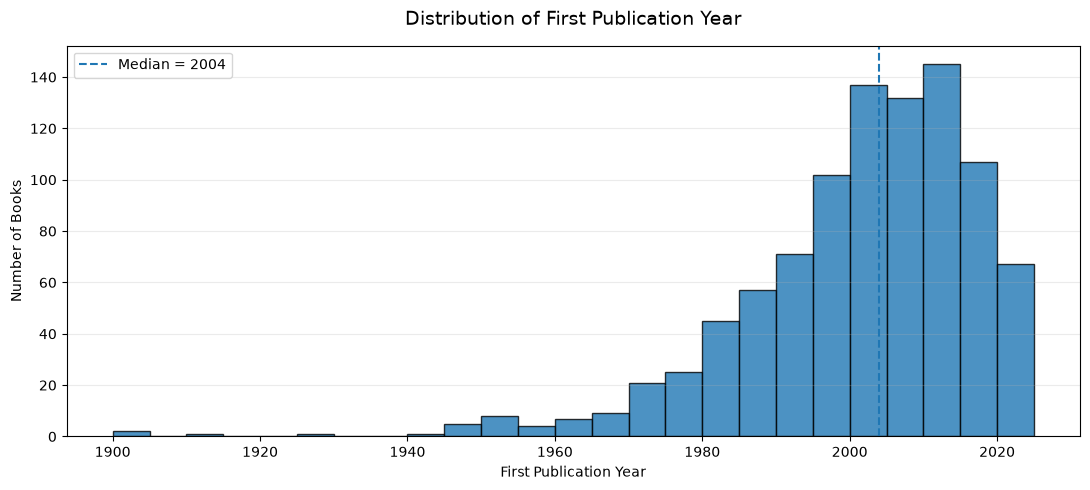

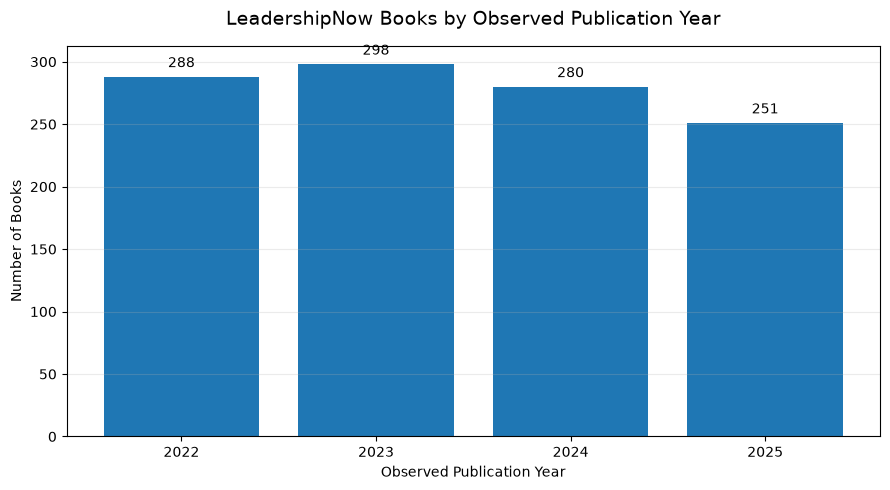

,year,book_count,percentage
0,2022,288,25.78%
1,2023,298,26.68%
2,2024,280,25.07%
3,2025,251,22.47%


In [11]:
# ============================================================
# PUBLICATION YEAR DISTRIBUTIONS
# ============================================================

first_year = (
    books["first_publish_year"]
    .dropna()
    .astype(int)
)

observed_year = (
    books["publication_year_observed"]
    .dropna()
    .astype(int)
)


# ------------------------------------------------------------
# First publication year
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(
    first_year,
    bins=25,
    edgecolor="black",
    alpha=0.8
)

ax.axvline(
    first_year.median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median = {first_year.median():.0f}"
)

ax.set_title(
    "Distribution of First Publication Year",
    fontsize=14,
    pad=15
)

ax.set_xlabel("First Publication Year")
ax.set_ylabel("Number of Books")

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# LeadershipNow observed publication year
# ------------------------------------------------------------

observed_counts = (
    observed_year
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    observed_counts.index.astype(str),
    observed_counts.values
)

ax.set_title(
    "LeadershipNow Books by Observed Publication Year",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Observed Publication Year")
ax.set_ylabel("Number of Books")

ax.grid(
    axis="y",
    alpha=0.25
)

for bar, count in zip(bars, observed_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Exact LeadershipNow year counts
# ------------------------------------------------------------

observed_year_table = (
    observed_counts
    .rename("book_count")
    .reset_index()
    .rename(columns={"publication_year_observed": "year"})
)

observed_year_table["percentage"] = (
    observed_year_table["book_count"] /
    observed_year_table["book_count"].sum()
    * 100
)

display(
    observed_year_table.style.format({
        "percentage": "{:.2f}%"
    })
)

### Publication Trend Interpretation

The temporal distributions reinforce the complementary nature of the two data sources.

The Open Library first-publication data provide the historical dimension of the catalogue, covering works published from 1900 through 2025. The median first publication year is 2004, indicating that the Open Library component contains both established leadership and management literature and more contemporary works.

In contrast, the LeadershipNow observed-publication data are intentionally recent. The 1,117 books are distributed relatively evenly across 2022–2025: 288 books (25.78%) in 2022, 298 (26.68%) in 2023, 280 (25.07%) in 2024, and 251 (22.47%) in 2025.

The largest observed year is 2023, but no individual year accounts for more than 27% of the LeadershipNow subset. This provides relatively balanced representation across the four recent publication years.

For later recommendation modelling, publication year can therefore provide a useful recency signal, but `first_publish_year` and `publication_year_observed` should remain conceptually separate because they describe different bibliographic events.

## 6. Author and Authorship Analysis

Author information is available for 99.61% of the catalogue.

This section examines:

- the number of authors associated with each book
- single-author versus multi-author works
- the most frequently represented authors
- the degree of author concentration in the catalogue

Authorship frequency represents presence within this dataset and should not be interpreted as a measure of author quality, influence, or importance.

AUTHOR COUNT DISTRIBUTION


,number_of_authors,book_count,percentage
0,0,8,0.39%
1,1,1764,85.34%
2,2,162,7.84%
3,3,80,3.87%
4,4,25,1.21%
5,5,20,0.97%
6,6,3,0.15%
7,7,4,0.19%
8,11,1,0.05%



AUTHORSHIP SUMMARY
Books with no author:       8
Single-author books:        1,764
Multi-author books:         295
Maximum authors on one book: 11
Mean authors per book:      1.25

TOP 20 MOST REPRESENTED AUTHORS


,author,book_count,percentage_of_catalogue
0,Michael Armstrong,12,0.58%
1,Gary Dessler,8,0.39%
2,Jay Heizer,7,0.34%
3,John C. Maxwell,6,0.29%
4,Bernard M. Bass,6,0.29%
5,Ronald B. Adler,6,0.29%
6,Daniel Goleman,6,0.29%
7,Bruce J. Avolio,5,0.24%
8,Fred R. David,5,0.24%
9,Stephen P. Robbins,5,0.24%


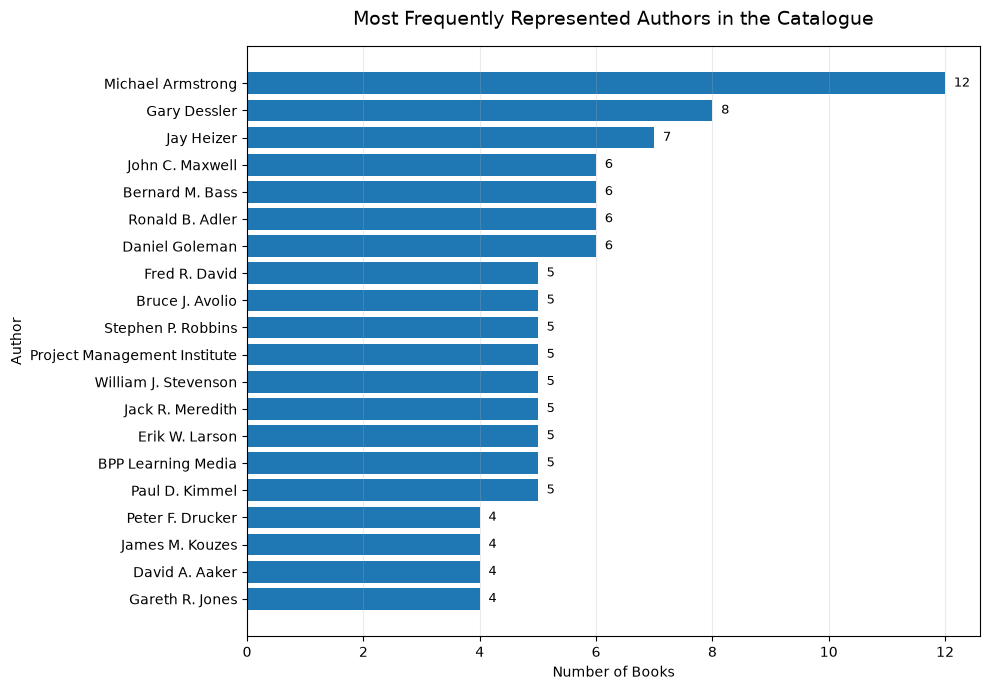

In [12]:
# ============================================================
# AUTHORSHIP EDA
# ============================================================

import ast
from collections import Counter


def parse_list_field(value):
    """
    Safely parse serialized list-like fields.
    Returns an empty list for missing or invalid values.
    """
    if pd.isna(value):
        return []

    if isinstance(value, list):
        return value

    text = str(value).strip()

    if text in {"", "[]", "nan", "None", "null"}:
        return []

    try:
        parsed = ast.literal_eval(text)

        if isinstance(parsed, list):
            return [
                str(item).strip()
                for item in parsed
                if str(item).strip()
            ]

    except (ValueError, SyntaxError):
        pass

    # Conservative fallback:
    # preserve the complete value rather than splitting names
    return [text]


# ------------------------------------------------------------
# Parse author lists
# ------------------------------------------------------------

books["authors_list"] = books["authors"].apply(parse_list_field)

books["author_count"] = books["authors_list"].apply(len)


# ------------------------------------------------------------
# Authorship distribution
# ------------------------------------------------------------

author_count_distribution = (
    books["author_count"]
    .value_counts()
    .sort_index()
    .rename_axis("number_of_authors")
    .reset_index(name="book_count")
)

author_count_distribution["percentage"] = (
    author_count_distribution["book_count"]
    / len(books)
    * 100
)

print("AUTHOR COUNT DISTRIBUTION")
print("=" * 70)

display(
    author_count_distribution.style.format({
        "percentage": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nAUTHORSHIP SUMMARY")
print("=" * 70)

print(
    f"Books with no author:       "
    f"{(books['author_count'] == 0).sum():,}"
)

print(
    f"Single-author books:        "
    f"{(books['author_count'] == 1).sum():,}"
)

print(
    f"Multi-author books:         "
    f"{(books['author_count'] > 1).sum():,}"
)

print(
    f"Maximum authors on one book:"
    f" {books['author_count'].max():,}"
)

print(
    f"Mean authors per book:      "
    f"{books['author_count'].mean():.2f}"
)


# ------------------------------------------------------------
# Flatten authors
# ------------------------------------------------------------

author_counter = Counter(
    author
    for author_list in books["authors_list"]
    for author in author_list
)

top_authors = pd.DataFrame(
    author_counter.most_common(20),
    columns=["author", "book_count"]
)

top_authors["percentage_of_catalogue"] = (
    top_authors["book_count"]
    / len(books)
    * 100
)

print("\nTOP 20 MOST REPRESENTED AUTHORS")
print("=" * 70)

display(
    top_authors.style.format({
        "percentage_of_catalogue": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# Visualize top authors
# ------------------------------------------------------------

plot_authors = (
    top_authors
    .sort_values("book_count", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    plot_authors["author"],
    plot_authors["book_count"]
)

ax.set_title(
    "Most Frequently Represented Authors in the Catalogue",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Number of Books")
ax.set_ylabel("Author")

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, count in zip(
    bars,
    plot_authors["book_count"]
):
    ax.text(
        count + 0.15,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Authorship Interpretation

Authorship metadata are highly complete, with only **8 books (0.39%)** lacking usable author information.

The catalogue is predominantly composed of individually authored works. **1,764 books (85.34%)** have one author, while **295 books (14.27%)** have two or more authors. The mean is **1.25 authors per book**, and the maximum observed authorship is 11 authors.

Author representation is also highly dispersed. The most frequently represented author, **Michael Armstrong**, appears in only 12 books, representing approximately **0.58% of the entire catalogue**. No other author accounts for even 0.5% of the catalogue.

This suggests that the dataset is not strongly dominated by a small group of prolific authors. For the recommendation system, author information can therefore provide a useful similarity feature without a small number of authors automatically dominating the catalogue.

However, author frequency represents only the number of books present in this dataset. It should not be interpreted as a measure of author influence, quality, popularity, or authority.

## 7. Subject and Semantic Metadata Analysis

Subject metadata provide structured information about the themes and topics associated with books and can therefore contribute directly to content-based recommendation.

This section examines:

- subject availability
- number of subjects assigned per book
- unique subject vocabulary
- most frequently occurring subjects
- concentration and fragmentation of the subject space

Source-derived subjects are treated as bibliographic metadata. They should not be interpreted as equivalent to NLP-generated topics or machine-learning clusters.

SUBJECT METADATA SUMMARY
Total books:                    2,067
Books with subjects:            826
Books without subjects:         1,241
Subject coverage:               39.96%
Total subject assignments:      5,984
Unique subject labels:          2,300
Mean subjects per all books:    2.90
Mean subjects when available:   7.24
Median subjects when available: 5
Maximum subjects on one book:   59

SUBJECT COUNT DISTRIBUTION


,number_of_subjects,book_count,percentage_of_books_with_subjects
0,1,118,14.29%
1,2,117,14.16%
2,3,81,9.81%
3,4,59,7.14%
4,5,75,9.08%
5,6,43,5.21%
6,7,46,5.57%
7,8,41,4.96%
8,9,39,4.72%
9,10,27,3.27%



TOP 25 MOST FREQUENT SUBJECTS


,subject,book_count,percentage_of_subject_books
0,Management,247,29.90%
1,Leadership,186,22.52%
2,Personnel management,95,11.50%
3,Strategic planning,86,10.41%
4,Gestion,75,9.08%
5,BUSINESS & ECONOMICS,67,8.11%
6,Industrial management,64,7.75%
7,Organizational behavior,64,7.75%
8,Organizational change,61,7.38%
9,Case studies,57,6.90%



SUBJECT VOCABULARY FRAGMENTATION
Subjects appearing once:        1,649
Percentage appearing once:      71.70%
Subjects appearing >= 2 times:  651
Subjects appearing >= 5 times:  185
Subjects appearing >= 10 times: 102


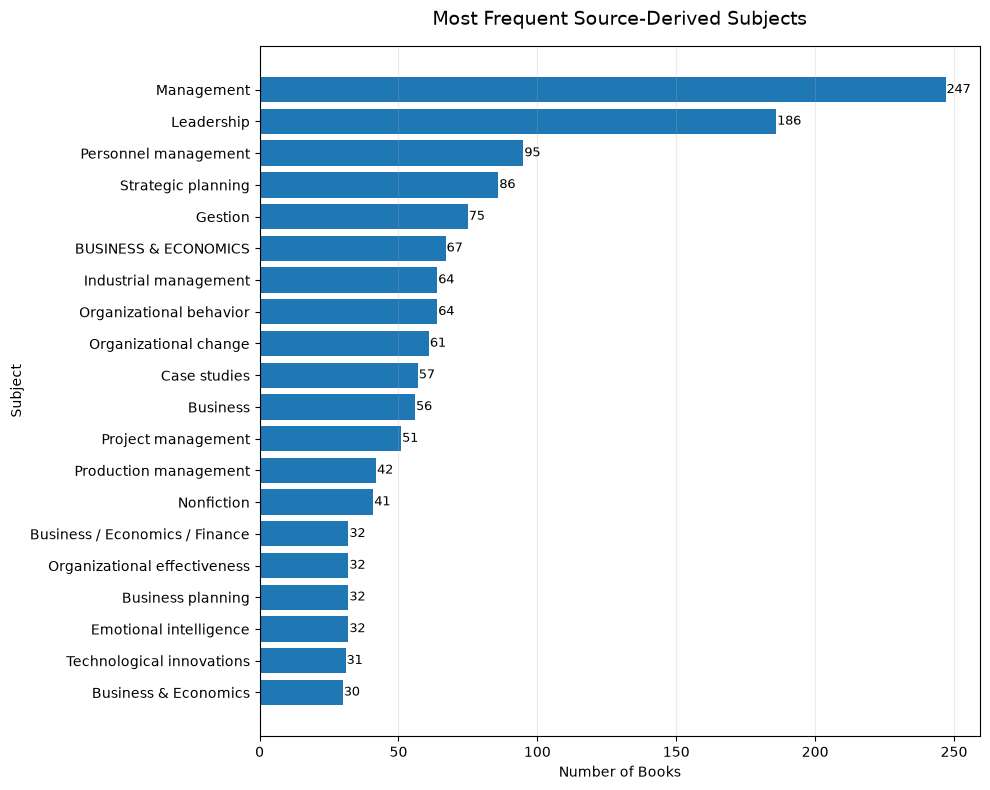

In [13]:
# ============================================================
# SUBJECT EDA
# ============================================================

# Parse subjects using the same safe list parser
books["subjects_list"] = books["subjects"].apply(parse_list_field)

books["subject_count"] = books["subjects_list"].apply(len)


# ------------------------------------------------------------
# Basic subject statistics
# ------------------------------------------------------------

books_with_subjects = (books["subject_count"] > 0).sum()
books_without_subjects = (books["subject_count"] == 0).sum()

all_subjects = [
    subject
    for subject_list in books["subjects_list"]
    for subject in subject_list
]

subject_counter = Counter(all_subjects)

unique_subjects = len(subject_counter)


print("SUBJECT METADATA SUMMARY")
print("=" * 70)

print(f"Total books:                    {len(books):,}")
print(f"Books with subjects:            {books_with_subjects:,}")
print(f"Books without subjects:         {books_without_subjects:,}")
print(
    f"Subject coverage:               "
    f"{books_with_subjects / len(books) * 100:.2f}%"
)

print(f"Total subject assignments:      {len(all_subjects):,}")
print(f"Unique subject labels:          {unique_subjects:,}")

print(
    f"Mean subjects per all books:    "
    f"{books['subject_count'].mean():.2f}"
)

print(
    f"Mean subjects when available:   "
    f"{books.loc[books['subject_count'] > 0, 'subject_count'].mean():.2f}"
)

print(
    f"Median subjects when available: "
    f"{books.loc[books['subject_count'] > 0, 'subject_count'].median():.0f}"
)

print(
    f"Maximum subjects on one book:   "
    f"{books['subject_count'].max():,}"
)


# ------------------------------------------------------------
# Distribution of number of subjects
# ------------------------------------------------------------

subject_count_distribution = (
    books.loc[
        books["subject_count"] > 0,
        "subject_count"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("number_of_subjects")
    .reset_index(name="book_count")
)

subject_count_distribution["percentage_of_books_with_subjects"] = (
    subject_count_distribution["book_count"]
    / books_with_subjects
    * 100
)

print("\nSUBJECT COUNT DISTRIBUTION")
print("=" * 70)

display(
    subject_count_distribution.head(20).style.format({
        "percentage_of_books_with_subjects": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# Top subjects
# ------------------------------------------------------------

top_subjects = pd.DataFrame(
    subject_counter.most_common(25),
    columns=[
        "subject",
        "book_count"
    ]
)

top_subjects["percentage_of_subject_books"] = (
    top_subjects["book_count"]
    / books_with_subjects
    * 100
)

print("\nTOP 25 MOST FREQUENT SUBJECTS")
print("=" * 70)

display(
    top_subjects.style.format({
        "percentage_of_subject_books": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# Subject vocabulary frequency
# ------------------------------------------------------------

subject_frequency_distribution = (
    pd.Series(list(subject_counter.values()))
    .value_counts()
    .sort_index()
)

single_use_subjects = sum(
    count == 1
    for count in subject_counter.values()
)

print("\nSUBJECT VOCABULARY FRAGMENTATION")
print("=" * 70)

print(
    f"Subjects appearing once:        "
    f"{single_use_subjects:,}"
)

print(
    f"Percentage appearing once:      "
    f"{single_use_subjects / unique_subjects * 100:.2f}%"
)

print(
    f"Subjects appearing >= 2 times:  "
    f"{sum(count >= 2 for count in subject_counter.values()):,}"
)

print(
    f"Subjects appearing >= 5 times:  "
    f"{sum(count >= 5 for count in subject_counter.values()):,}"
)

print(
    f"Subjects appearing >= 10 times: "
    f"{sum(count >= 10 for count in subject_counter.values()):,}"
)


# ------------------------------------------------------------
# Top-subject visualization
# ------------------------------------------------------------

plot_subjects = (
    top_subjects
    .head(20)
    .sort_values("book_count", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    plot_subjects["subject"],
    plot_subjects["book_count"]
)

ax.set_title(
    "Most Frequent Source-Derived Subjects",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Number of Books")
ax.set_ylabel("Subject")

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, count in zip(
    bars,
    plot_subjects["book_count"]
):
    ax.text(
        count + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Subject Metadata Interpretation

Subject metadata are available for **826 books (39.96%)**, containing **5,984 subject assignments** across **2,300 unique subject labels**. Books with subject metadata contain an average of **7.24 subjects**, with a median of 5 and a maximum of 59.

The most frequently represented subjects align closely with the project's domain. `Management` appears in 247 books (29.90% of books with subjects), followed by `Leadership` in 186 (22.52%), `Personnel management` in 95 (11.50%), and `Strategic planning` in 86 (10.41%).

The subject vocabulary is highly fragmented. **1,649 of the 2,300 unique labels (71.70%) occur only once**, while only 102 subjects occur in at least 10 books.

The raw vocabulary also contains lexical and formatting variations, including `BUSINESS & ECONOMICS`, `Business & Economics`, `Business/Economics`, and related labels. Multilingual labels such as `Gestion` are also present.

These findings indicate that raw subjects should not simply be converted into thousands of independent categorical dummy variables. Later NLP preprocessing should normalize textual representations and use methods such as TF-IDF to capture semantic term importance. Dimensionality reduction can subsequently address the resulting high-dimensional sparse feature space before clustering and recommendation modelling.

Source-derived subjects remain distinct from NLP-generated topics and machine-learning clusters.

METRIC DESCRIPTIVE STATISTICS


,metric,count,mean,std,min,25%,50%,75%,max
0,average_rating,282,3.88,1.41,0.00,3.50,4.27,5.00,5.00
1,ratings_count,282,4.62,17.72,0.00,1.00,1.50,4.00,278.00
2,want_to_read_count,807,47.49,266.80,0.00,3.00,9.00,30.00,"6,754.00"
3,currently_reading_count,807,3.93,24.90,0.00,0.00,1.00,2.00,643.00
4,already_read_count,807,2.31,14.05,0.00,0.00,0.00,1.00,328.00
5,edition_count,950,7.28,9.86,1.00,2.00,4.00,8.00,95.00


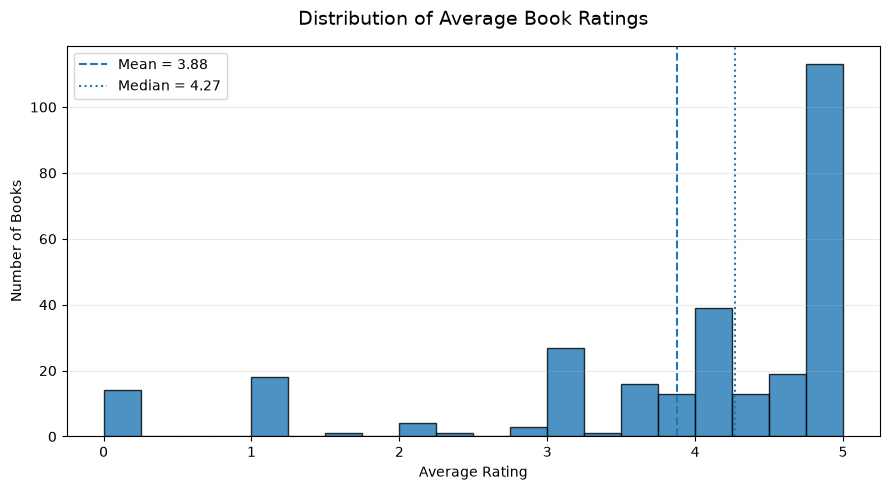


ENGAGEMENT DISTRIBUTION / SKEWNESS


,metric,available_books,mean,median,maximum,skewness
0,ratings_count,282,4.62,1.50,278,13.49
1,want_to_read_count,807,47.49,9.00,"6,754",20.85
2,currently_reading_count,807,3.93,1.00,643,21.88
3,already_read_count,807,2.31,0.00,328,17.87


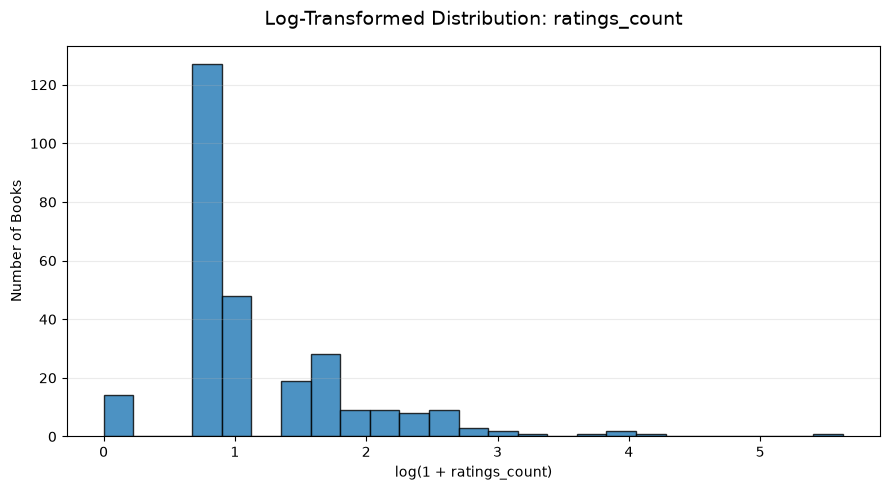

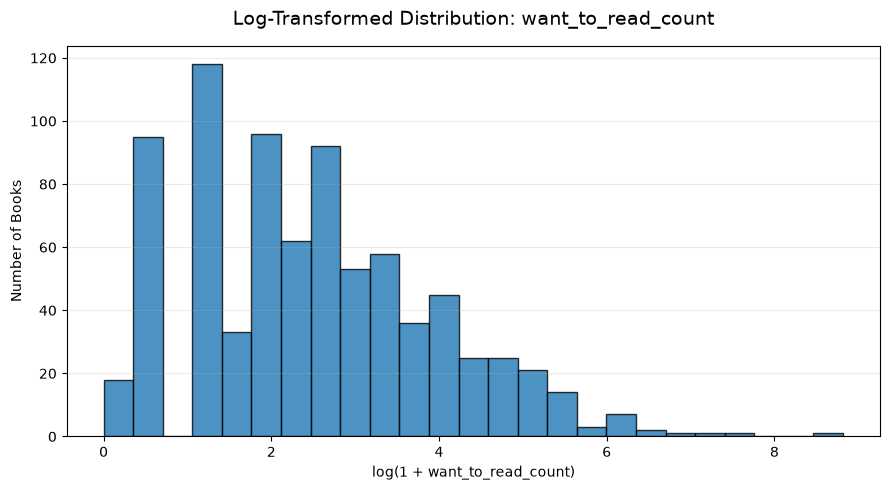

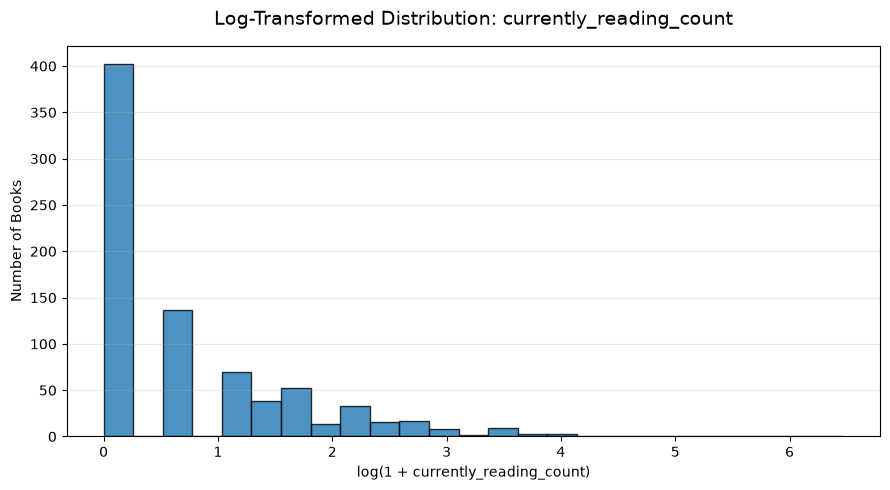

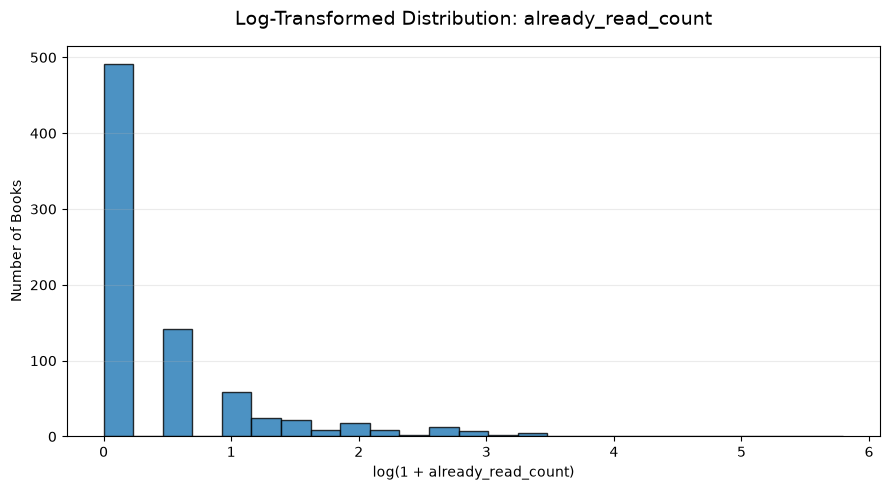

In [14]:
# ============================================================
# RATINGS AND READER ENGAGEMENT EDA
# ============================================================

metric_columns = [
    "average_rating",
    "ratings_count",
    "want_to_read_count",
    "currently_reading_count",
    "already_read_count",
    "edition_count"
]

# ------------------------------------------------------------
# Descriptive statistics
# ------------------------------------------------------------

metric_summary = (
    books[metric_columns]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

print("METRIC DESCRIPTIVE STATISTICS")
print("=" * 80)

display(
    metric_summary.style.format({
        "count": "{:,.0f}",
        "mean": "{:,.2f}",
        "std": "{:,.2f}",
        "min": "{:,.2f}",
        "25%": "{:,.2f}",
        "50%": "{:,.2f}",
        "75%": "{:,.2f}",
        "max": "{:,.2f}"
    })
)


# ------------------------------------------------------------
# Rating distribution
# ------------------------------------------------------------

rating_data = books["average_rating"].dropna()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    rating_data,
    bins=20,
    edgecolor="black",
    alpha=0.8
)

ax.axvline(
    rating_data.mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {rating_data.mean():.2f}"
)

ax.axvline(
    rating_data.median(),
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {rating_data.median():.2f}"
)

ax.set_title(
    "Distribution of Average Book Ratings",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Average Rating")
ax.set_ylabel("Number of Books")

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Engagement skewness
# ------------------------------------------------------------

engagement_columns = [
    "ratings_count",
    "want_to_read_count",
    "currently_reading_count",
    "already_read_count"
]

skewness_results = []

for col in engagement_columns:

    data = books[col].dropna()

    skewness_results.append({
        "metric": col,
        "available_books": len(data),
        "mean": data.mean(),
        "median": data.median(),
        "maximum": data.max(),
        "skewness": data.skew()
    })

engagement_skewness = pd.DataFrame(skewness_results)

print("\nENGAGEMENT DISTRIBUTION / SKEWNESS")
print("=" * 80)

display(
    engagement_skewness.style.format({
        "mean": "{:,.2f}",
        "median": "{:,.2f}",
        "maximum": "{:,.0f}",
        "skewness": "{:.2f}"
    })
)


# ------------------------------------------------------------
# Log-transformed engagement distributions
# ------------------------------------------------------------

for col in engagement_columns:

    data = books[col].dropna()

    log_data = np.log1p(data)

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.hist(
        log_data,
        bins=25,
        edgecolor="black",
        alpha=0.8
    )

    ax.set_title(
        f"Log-Transformed Distribution: {col}",
        fontsize=14,
        pad=15
    )

    ax.set_xlabel(f"log(1 + {col})")
    ax.set_ylabel("Number of Books")

    ax.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

### Ratings and Reader-Engagement Interpretation

Ratings and reader-engagement variables are available only for subsets of the catalogue and therefore should not be interpreted as representative of all 2,067 books.

Average ratings are available for 282 books. The mean observed rating is **3.88**, while the median is **4.27**. Ratings range from 0 to 5. Because rating coverage is only 13.64%, ratings should be treated as supplementary information rather than a universal indicator of book quality.

Reader-engagement measures show extreme positive skewness. `ratings_count` has a skewness of **13.49**, `want_to_read_count` **20.85**, `currently_reading_count` **21.88**, and `already_read_count` **17.87**.

The differences between means and medians demonstrate the effect of a small number of highly engaged books. For example, `want_to_read_count` has a median of only 9 but a mean of 47.49 and a maximum of 6,754.

These distributions indicate that raw engagement counts would allow a small number of extreme observations to dominate distance-based or scale-sensitive modelling. The log-transformed distributions therefore provide a more appropriate representation for later feature engineering.

Accordingly, `log1p()` transformation of engagement-count variables will be considered during the feature-engineering stage. The original values will remain preserved for interpretation and reporting.

Engagement measures represent observed reader activity in the source data and should not be interpreted as direct measures of book quality.

RATING VS RATING-COUNT ASSOCIATION
Books analysed:        282
Pearson correlation:   0.035
Spearman correlation:  -0.037
Pearson with log count:   0.228


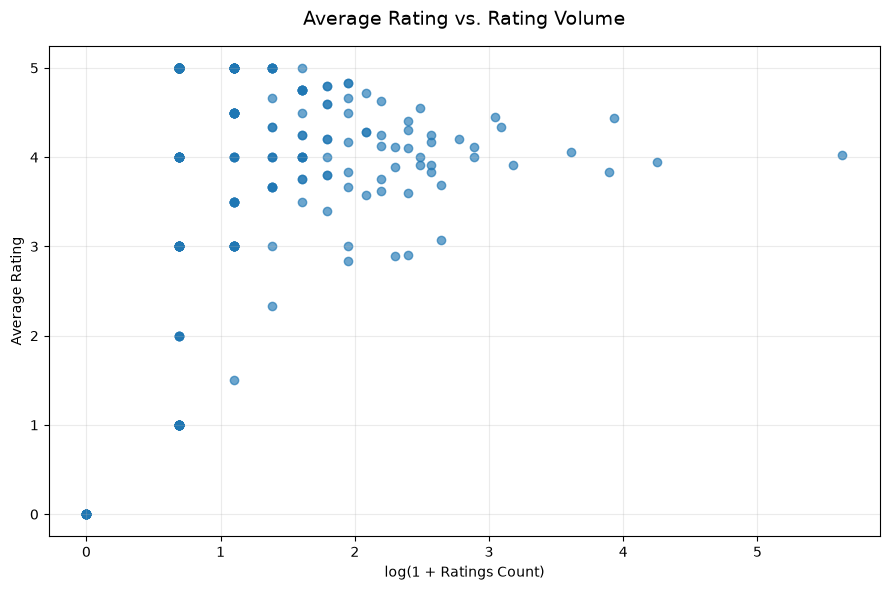


BOOKS WITH THE HIGHEST OBSERVED RATING VOLUME


,canonical_title,average_rating,ratings_count
332,The 7 Habits of Highly Effective People,4.03,278
855,Emotional Intelligence,3.94,69
282,Marketing Management,4.44,50
470,Rework,3.83,48
280,Marketing management,4.06,36
733,The 33 Strategies of War,3.91,23
442,The Manager's Path,4.33,21
808,Nonviolent Communication,4.45,20
914,The Innovator's Dilemma,4.00,17
166,Leaders Eat Last,4.12,17


In [15]:
# ============================================================
# RATING VS POPULARITY ANALYSIS
# ============================================================

rating_analysis = books[
    [
        "book_id",
        "canonical_title",
        "average_rating",
        "ratings_count"
    ]
].dropna(
    subset=[
        "average_rating",
        "ratings_count"
    ]
).copy()


# ------------------------------------------------------------
# Pearson and Spearman correlations
# ------------------------------------------------------------

pearson_corr = rating_analysis[
    ["average_rating", "ratings_count"]
].corr(
    method="pearson"
).iloc[0, 1]

spearman_corr = rating_analysis[
    ["average_rating", "ratings_count"]
].corr(
    method="spearman"
).iloc[0, 1]


print("RATING VS RATING-COUNT ASSOCIATION")
print("=" * 70)

print(f"Books analysed:        {len(rating_analysis):,}")
print(f"Pearson correlation:   {pearson_corr:.3f}")
print(f"Spearman correlation:  {spearman_corr:.3f}")


# ------------------------------------------------------------
# Correlation after log transformation of rating volume
# ------------------------------------------------------------

rating_analysis["log_ratings_count"] = np.log1p(
    rating_analysis["ratings_count"]
)

log_pearson = rating_analysis[
    ["average_rating", "log_ratings_count"]
].corr(
    method="pearson"
).iloc[0, 1]

print(
    f"Pearson with log count:{log_pearson:>8.3f}"
)


# ------------------------------------------------------------
# Scatter plot using log rating count
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    rating_analysis["log_ratings_count"],
    rating_analysis["average_rating"],
    alpha=0.65
)

ax.set_title(
    "Average Rating vs. Rating Volume",
    fontsize=14,
    pad=15
)

ax.set_xlabel("log(1 + Ratings Count)")
ax.set_ylabel("Average Rating")

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Highest rating-volume books
# ------------------------------------------------------------

top_rating_volume = (
    rating_analysis
    .sort_values(
        "ratings_count",
        ascending=False
    )
    .head(15)
    [
        [
            "canonical_title",
            "average_rating",
            "ratings_count"
        ]
    ]
)

print("\nBOOKS WITH THE HIGHEST OBSERVED RATING VOLUME")
print("=" * 70)

display(
    top_rating_volume.style.format({
        "average_rating": "{:.2f}",
        "ratings_count": "{:,.0f}"
    })
)

### Rating and Popularity Relationship

Among the 282 books with both rating and rating-count information, the relationship between average rating and rating volume is weak.

The raw Pearson correlation is **0.035**, indicating virtually no linear association between average rating and the number of ratings. The Spearman correlation is similarly close to zero at **−0.037**, suggesting little monotonic relationship between the two variables.

After applying a `log1p()` transformation to rating volume, the Pearson correlation increases to **0.228**. This indicates a modest positive linear association after reducing the influence of extremely high rating counts, but the relationship remains limited.

These findings demonstrate that **rating score and popularity are distinct dimensions** in this dataset. A book receiving many ratings does not necessarily receive a higher average rating, while highly rated books are not necessarily the most frequently rated.

For the recommendation system, average rating and engagement/popularity measures should therefore remain separate features rather than being treated as interchangeable indicators. Rating information should also remain supplementary because it is available for only 282 books.

The books with the highest observed rating volumes represent source-specific engagement within the available dataset and should not be interpreted as an objective ranking of the best leadership and management books.

EDITION DATASET
Edition records:        1,120
Unique canonical books: 1,120
Unique scrape IDs:      1,120

PUBLISHER COVERAGE
Publisher available:    1,120 / 1,120 (100.00%)
Publisher missing:      0

TOP 20 PUBLISHERS


,publisher,edition_count,percentage_of_editions
0,Wiley,126,11.25%
1,Harvard Business Review Press,67,5.98%
2,Berrett-Koehler Publishers,41,3.66%
3,Matt Holt,33,2.95%
4,Portfolio,28,2.50%
5,Harper Business,26,2.32%
6,HarperCollins Leadership,22,1.96%
7,St. Martin's Press,19,1.70%
8,Amplify Publishing,19,1.70%
9,ForbesBooks,19,1.70%



EDITION FORMAT DISTRIBUTION


,format,edition_count,percentage
0,Hardcover,924,82.50%
1,Paperback,196,17.50%



PAGE COUNT SUMMARY
Available:    1,119
Missing:      1
Mean:         278.58
Median:       256.00
Minimum:      96
Maximum:      1,200
Skewness:     3.00


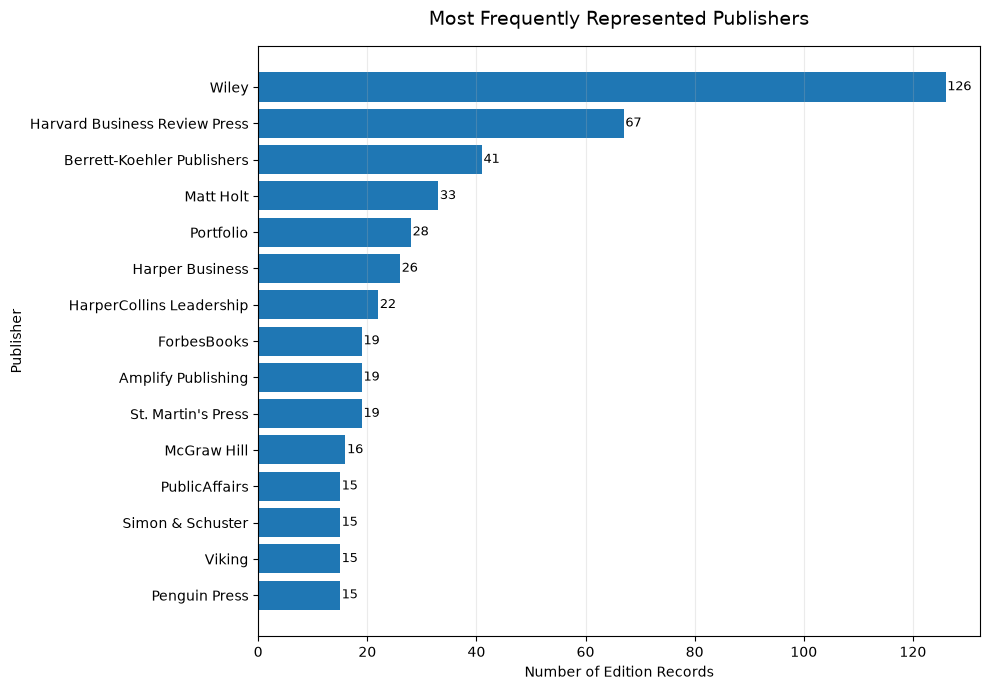

In [16]:
# ============================================================
# EDITION AND PUBLISHER EDA
# ============================================================

print("EDITION DATASET")
print("=" * 75)

print(f"Edition records:        {len(editions):,}")
print(f"Unique canonical books: {editions['book_id'].nunique():,}")
print(f"Unique scrape IDs:      {editions['scrape_id'].nunique():,}")


# ------------------------------------------------------------
# Publisher coverage
# ------------------------------------------------------------

publisher_clean = (
    editions["publisher"]
    .fillna("")
    .astype(str)
    .str.strip()
)

publisher_available = publisher_clean.ne("")

print("\nPUBLISHER COVERAGE")
print("=" * 75)

print(
    f"Publisher available:    "
    f"{publisher_available.sum():,} / {len(editions):,} "
    f"({publisher_available.mean() * 100:.2f}%)"
)

print(
    f"Publisher missing:      "
    f"{(~publisher_available).sum():,}"
)


# ------------------------------------------------------------
# Top publishers
# ------------------------------------------------------------

top_publishers = (
    editions.loc[publisher_available, "publisher"]
    .astype(str)
    .str.strip()
    .value_counts()
    .head(20)
    .rename_axis("publisher")
    .reset_index(name="edition_count")
)

top_publishers["percentage_of_editions"] = (
    top_publishers["edition_count"]
    / len(editions)
    * 100
)

print("\nTOP 20 PUBLISHERS")
print("=" * 75)

display(
    top_publishers.style.format({
        "percentage_of_editions": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# Format distribution
# ------------------------------------------------------------

format_clean = (
    editions["format"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .replace("", "Unknown")
)

format_distribution = (
    format_clean
    .value_counts()
    .rename_axis("format")
    .reset_index(name="edition_count")
)

format_distribution["percentage"] = (
    format_distribution["edition_count"]
    / len(editions)
    * 100
)

print("\nEDITION FORMAT DISTRIBUTION")
print("=" * 75)

display(
    format_distribution.style.format({
        "percentage": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# Page-count statistics
# ------------------------------------------------------------

page_data = editions["page_count"].dropna()

print("\nPAGE COUNT SUMMARY")
print("=" * 75)

print(f"Available:    {len(page_data):,}")
print(f"Missing:      {editions['page_count'].isna().sum():,}")

if len(page_data) > 0:
    print(f"Mean:         {page_data.mean():,.2f}")
    print(f"Median:       {page_data.median():,.2f}")
    print(f"Minimum:      {page_data.min():,.0f}")
    print(f"Maximum:      {page_data.max():,.0f}")
    print(f"Skewness:     {page_data.skew():,.2f}")


# ------------------------------------------------------------
# Top publishers visualization
# ------------------------------------------------------------

plot_publishers = (
    top_publishers
    .head(15)
    .sort_values("edition_count")
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    plot_publishers["publisher"],
    plot_publishers["edition_count"]
)

ax.set_title(
    "Most Frequently Represented Publishers",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Number of Edition Records")
ax.set_ylabel("Publisher")

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, count in zip(
    bars,
    plot_publishers["edition_count"]
):
    ax.text(
        count + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Edition and Publisher Interpretation

The LeadershipNow edition dataset contains **1,120 edition records representing 1,120 unique canonical books and 1,120 unique scrape IDs**. This confirms a one-to-one relationship between the retained LeadershipNow edition records and canonical books in this analytical dataset.

Publisher metadata are complete, with publisher information available for all 1,120 edition records. The publisher distribution is relatively diverse, although several publishers have stronger representation. **Wiley** is the most frequently represented publisher with 126 editions (11.25%), followed by **Harvard Business Review Press** with 67 (5.98%) and **Berrett-Koehler Publishers** with 41 (3.66%). No single publisher dominates the collection.

The edition format distribution is substantially concentrated in hardcover books. **924 editions (82.50%)** are hardcover and **196 (17.50%)** are paperback. This distribution describes the LeadershipNow catalogue and should not be generalized to leadership and management publishing overall.

Page-count information is nearly complete, with **1,119 of 1,120 editions** containing a value. The median book length is **256 pages**, compared with a mean of **278.58 pages**. Page counts range from 96 to 1,200 pages and have a positive skewness of **3.00**, indicating that a relatively small number of long books extend the upper tail of the distribution.

As with reader-engagement variables, unusually high page counts should not automatically be removed as outliers. They may represent legitimate long-form publications and should first be inspected before any feature-engineering decision is made.

In [17]:
# ============================================================
# FINAL EDA DIAGNOSTICS
# Missingness + Potential Extreme Values
# ============================================================

# ------------------------------------------------------------
# 1. Core metadata availability combinations
# ------------------------------------------------------------

books["has_authors"] = books["authors_list"].apply(len) > 0
books["has_subjects"] = books["subjects_list"].apply(len) > 0
books["has_description"] = semantic_available(books["description"])
books["has_rating"] = books["average_rating"].notna()
books["has_engagement"] = books[
    [
        "want_to_read_count",
        "currently_reading_count",
        "already_read_count"
    ]
].notna().any(axis=1)


print("CORE METADATA AVAILABILITY")
print("=" * 75)

availability_summary = pd.DataFrame({
    "feature": [
        "Authors",
        "Subjects",
        "Description",
        "Rating",
        "Reader engagement"
    ],
    "available_books": [
        books["has_authors"].sum(),
        books["has_subjects"].sum(),
        books["has_description"].sum(),
        books["has_rating"].sum(),
        books["has_engagement"].sum()
    ]
})

availability_summary["percentage"] = (
    availability_summary["available_books"]
    / len(books)
    * 100
)

display(
    availability_summary.style.format({
        "percentage": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 2. Text availability for later NLP
# ------------------------------------------------------------

books["has_title"] = semantic_available(
    books["canonical_title"]
)

books["has_any_semantic_text"] = (
    books["has_title"]
    | books["has_subjects"]
    | books["has_description"]
)

books["has_rich_semantic_text"] = (
    books["has_subjects"]
    | books["has_description"]
)


print("\nNLP TEXT AVAILABILITY")
print("=" * 75)

print(
    f"Title available:                 "
    f"{books['has_title'].sum():,} "
    f"({books['has_title'].mean() * 100:.2f}%)"
)

print(
    f"Title/subject/description:       "
    f"{books['has_any_semantic_text'].sum():,} "
    f"({books['has_any_semantic_text'].mean() * 100:.2f}%)"
)

print(
    f"Subject or description available:"
    f" {books['has_rich_semantic_text'].sum():,} "
    f"({books['has_rich_semantic_text'].mean() * 100:.2f}%)"
)

print(
    f"Both subject and description:    "
    f"{(books['has_subjects'] & books['has_description']).sum():,}"
)

print(
    f"Subject but no description:      "
    f"{(books['has_subjects'] & ~books['has_description']).sum():,}"
)

print(
    f"Description but no subject:      "
    f"{(~books['has_subjects'] & books['has_description']).sum():,}"
)


# ------------------------------------------------------------
# 3. Books with highest engagement
# ------------------------------------------------------------

engagement_view = books[
    [
        "book_id",
        "canonical_title",
        "average_rating",
        "ratings_count",
        "want_to_read_count",
        "currently_reading_count",
        "already_read_count"
    ]
].copy()

engagement_view["total_reader_engagement"] = (
    engagement_view[
        [
            "want_to_read_count",
            "currently_reading_count",
            "already_read_count"
        ]
    ]
    .fillna(0)
    .sum(axis=1)
)

print("\nHIGHEST OBSERVED READER ENGAGEMENT")
print("=" * 75)

display(
    engagement_view
    .sort_values(
        "total_reader_engagement",
        ascending=False
    )
    .head(10)
    .style.format({
        "average_rating": "{:.2f}",
        "ratings_count": "{:,.0f}",
        "want_to_read_count": "{:,.0f}",
        "currently_reading_count": "{:,.0f}",
        "already_read_count": "{:,.0f}",
        "total_reader_engagement": "{:,.0f}"
    })
)


# ------------------------------------------------------------
# 4. Longest editions
# ------------------------------------------------------------

print("\nLONGEST OBSERVED EDITIONS")
print("=" * 75)

longest_editions = (
    editions[
        [
            "book_id",
            "publisher",
            "publication_year",
            "format",
            "page_count"
        ]
    ]
    .dropna(subset=["page_count"])
    .sort_values(
        "page_count",
        ascending=False
    )
    .head(10)
)

display(
    longest_editions.style.format({
        "page_count": "{:,.0f}"
    })
)


# ------------------------------------------------------------
# 5. Final EDA integrity check
# ------------------------------------------------------------

assert len(books) == 2067
assert books["book_id"].nunique() == 2067
assert len(editions) == 1120
assert editions["book_id"].nunique() == 1120

print("\n" + "=" * 75)
print("✓ FINAL EDA INTEGRITY CHECK PASSED")
print("=" * 75)

CORE METADATA AVAILABILITY


,feature,available_books,percentage
0,Authors,2059,99.61%
1,Subjects,826,39.96%
2,Description,192,9.29%
3,Rating,282,13.64%
4,Reader engagement,807,39.04%



NLP TEXT AVAILABILITY
Title available:                 2,067 (100.00%)
Title/subject/description:       2,067 (100.00%)
Subject or description available: 829 (40.11%)
Both subject and description:    189
Subject but no description:      637
Description but no subject:      3

HIGHEST OBSERVED READER ENGAGEMENT


,book_id,canonical_title,average_rating,ratings_count,want_to_read_count,currently_reading_count,already_read_count,total_reader_engagement
332,BOOK00333,The 7 Habits of Highly Effective People,4.03,278,"6,754",643,328,"7,725"
855,BOOK00856,Emotional Intelligence,3.94,69,"2,335",200,106,"2,641"
280,BOOK00281,Marketing management,4.06,36,"1,351",125,73,"1,549"
282,BOOK00283,Marketing Management,4.44,50,"1,087",87,154,"1,328"
733,BOOK00734,The 33 Strategies of War,3.91,23,759,40,28,827
281,BOOK00282,Management information systems,4.10,10,686,59,30,775
470,BOOK00471,Rework,3.83,48,483,53,59,595
659,BOOK00660,Organizational Behavior,4.25,12,512,41,26,579
708,BOOK00709,Your Next Five Moves,3.08,13,516,21,12,549
856,BOOK00857,Emotional Intelligence 2.0,3.89,9,499,29,18,546



LONGEST OBSERVED EDITIONS


,book_id,publisher,publication_year,format,page_count
128,BOOK01079,Penguin Press,2025,Hardcover,"1,200"
983,BOOK01931,Heroic Blackstone,2023,Hardcover,"1,001"
238,BOOK01188,Liveright,2024,Hardcover,880
1,BOOK00952,Harper,2023,Hardcover,848
952,BOOK01900,Avid Reader Press,2022,Hardcover,832
130,BOOK01081,Portfolio,2022,Hardcover,816
227,BOOK01177,Princeton University Press,2023,Hardcover,816
135,BOOK01086,Dutton,2024,Hardcover,784
223,BOOK01173,Viking,2022,Hardcover,752
330,BOOK01278,Henry Holt and Co.,2024,Hardcover,732



✓ FINAL EDA INTEGRITY CHECK PASSED


# 8. EDA Conclusions and Model Readiness

Exploratory data analysis was conducted on the integrated catalogue of **2,067 unique leadership and management books**, together with **1,120 LeadershipNow edition records**. The analysis confirms that the integrated dataset is structurally sound and suitable for subsequent statistical analysis, feature engineering, NLP, clustering, and recommendation modelling.

## 8.1 Catalogue Composition

The final catalogue consists of:

- **1,117 LeadershipNow-only books (54.04%)**
- **947 Open Library-only books (45.82%)**
- **3 books represented in both sources (0.15%)**

The limited overlap demonstrates that the two sources are largely complementary. Their integration substantially expands catalogue coverage rather than primarily duplicating the same books.

## 8.2 Metadata Completeness

Metadata availability varies substantially across variables:

- Titles: **2,067 books (100.00%)**
- Authors: **2,059 books (99.61%)**
- Cover images: **1,888 books (91.34%)**
- Subjects: **826 books (39.96%)**
- Reader engagement: **807 books (39.04%)**
- Average ratings: **282 books (13.64%)**
- Descriptions: **192 books (9.29%)**

This missingness is largely associated with differences in source metadata rather than being treated automatically as data-quality failure.

Sparse fields such as ratings, descriptions, and engagement measures should therefore not be required for every recommendation.

## 8.3 Temporal Coverage

The dataset contains two conceptually different publication-year variables.

`first_publish_year` covers **1900–2025**, with a median of 2004, providing a historical perspective on leadership and management literature.

`publication_year_observed` covers **2022–2025** and represents the recent-release orientation of the LeadershipNow catalogue.

The LeadershipNow subset is relatively balanced across these years, with no single year accounting for more than 27% of the observed records.

The two publication-year variables should remain separate because they describe different bibliographic events.

## 8.4 Authorship

Authorship information is nearly complete.

Most books are individually authored:

- **1,764 books (85.34%)** have one author.
- **295 books (14.27%)** have multiple authors.
- **8 books (0.39%)** have no usable author metadata.

Author representation is highly dispersed. The most frequently represented author appears in only 12 books (0.58% of the catalogue), indicating that the dataset is not dominated by a small group of authors.

Author identity can therefore provide useful recommendation information without a small number of authors overwhelmingly determining catalogue composition.

## 8.5 Subject Vocabulary

Subjects provide important structured semantic information but are available for only **826 books (39.96%)**.

These books contain:

- **5,984 total subject assignments**
- **2,300 unique subject labels**
- an average of **7.24 subjects per book when available**
- a median of **5 subjects per book**

The subject vocabulary is highly fragmented. **1,649 subject labels (71.70%) occur only once**, while only 102 occur at least 10 times.

The vocabulary also contains lexical, formatting, and multilingual variations.

This strongly supports text normalization and vectorization rather than direct one-hot encoding of every raw subject label.

## 8.6 Ratings and Reader Engagement

Ratings and engagement measures are highly incomplete and should be treated as supplementary recommendation signals.

Average ratings are available for only **282 books (13.64%)**.

Reader-engagement measures are available for **807 books (39.04%)** and are extremely positively skewed:

- `ratings_count`: skewness **13.49**
- `want_to_read_count`: skewness **20.85**
- `currently_reading_count`: skewness **21.88**
- `already_read_count`: skewness **17.87**

Extreme engagement values appear to represent legitimate highly engaged books rather than automatically invalid observations. These records should therefore not be removed solely because they are statistical outliers.

A `log1p()` transformation should be considered during feature engineering to reduce the influence of extreme values while preserving their relative information.

## 8.7 Rating Versus Popularity

Average rating and rating volume show little association in their raw form.

Among the 282 books with both variables:

- Pearson correlation = **0.035**
- Spearman correlation = **−0.037**
- Pearson correlation after log-transforming rating count = **0.228**

This indicates that rating score and popularity represent different dimensions of reader response.

They should therefore remain separate features rather than being treated as interchangeable measures of book quality or popularity.

## 8.8 Edition Characteristics

The LeadershipNow edition dataset contains **1,120 edition records corresponding to 1,120 unique canonical books**.

Publisher information is complete. Wiley is the most represented publisher with 126 editions (11.25%), but no single publisher dominates the collection.

Edition format is concentrated in:

- Hardcover: **924 editions (82.50%)**
- Paperback: **196 editions (17.50%)**

Page-count information is available for 1,119 editions. The median is 256 pages, while the mean is 278.58 pages. Page count is positively skewed (3.00), with observed values ranging from 96 to 1,200 pages.

Long editions should be retained unless subsequent validation identifies specific erroneous records.

## 8.9 NLP Readiness

Every book has a usable title, meaning all **2,067 books can technically participate in a title-based textual representation**.

However, richer semantic metadata are unevenly distributed:

- **829 books (40.11%)** have a subject and/or description.
- **189 books** have both subjects and descriptions.
- **637 books** have subjects but no description.
- **3 books** have descriptions but no subjects.

Consequently, a description-only recommendation model would exclude most of the catalogue.

The NLP pipeline should instead construct a combined textual representation using available fields such as:

`title + authors + subjects + description`

while preserving the distinction between missing metadata and genuinely observed information.

TF-IDF is appropriate for constructing a sparse semantic representation, followed by dimensionality reduction where required for clustering and visualization.

## 8.10 Implications for the Recommendation System

The EDA supports a hybrid content-oriented recommendation architecture.

The strongest broadly available signals are:

1. **Book title**
2. **Author information**
3. **Subject metadata where available**
4. **Description where available**
5. **Publication/recency information**
6. **Reader engagement where available**
7. **Ratings where available**
8. **Edition characteristics where analytically appropriate**

Because metadata availability differs substantially between sources, the recommendation system should not depend on any single sparse variable.

The later modelling workflow should therefore prioritize semantic book similarity while using numerical metadata as supplementary features where appropriate.

Source-derived subjects, NLP-derived representations, and machine-learning clusters must remain conceptually distinct throughout the modelling process.

## 8.11 Final EDA Assessment

The EDA identified no structural issue requiring removal of large portions of the dataset.

The principal modelling challenges are instead:

- heterogeneous source coverage
- sparse descriptions
- sparse ratings
- fragmented subject vocabulary
- highly skewed engagement variables
- different temporal meanings across publication-year fields

These characteristics can be addressed through appropriate preprocessing, text normalization, transformation, feature engineering, dimensionality reduction, and model design.

**The dataset is therefore ready to proceed to statistical analysis and hypothesis testing.**